In [1]:
import sys
import os

# 1. Define the local path for PCGRL
pcgrl_path = r"C:\Users\prune\gym-pcgrl"
if pcgrl_path not in sys.path:
    sys.path.append(pcgrl_path)

print(f"{'Library':<20} | {'Status/Version':<20}")
print("-" * 45)

# 2. List of core libraries to check
libraries = [
    ("Python", lambda: sys.version.split()[0]),
    ("Gym", lambda: __import__('gym').__version__),
    ("TensorFlow", lambda: __import__('tensorflow').__version__),
    ("NumPy", lambda: __import__('numpy').__version__),
    ("Matplotlib", lambda: __import__('matplotlib').__version__),
    ("Pandas", lambda: __import__('pandas').__version__),
    ("Seaborn", lambda: __import__('seaborn').__version__),
    ("Pillow (PIL)", lambda: __import__('PIL').__version__),
]

for name, get_version in libraries:
    try:
        print(f"{name:<20} | {get_version():<20}")
    except ImportError:
        print(f"{name:<20} | NOT INSTALLED")

# 3. Specific check for the local gym-pcgrl import
try:
    from gym_pcgrl.envs.pcgrl_env import PcgrlEnv
    print(f"{'gym-pcgrl':<20} | SUCCESS (Local Import)")
except ImportError:
    print(f"{'gym-pcgrl':<20} | FAILED (Check Path: {pcgrl_path})")

# 4. Check GPU visibility for TensorFlow
import tensorflow as tf
gpu_devices = tf.config.list_physical_devices('GPU')
print(f"{'GPU Available':<20} | {len(gpu_devices)} discovered")

Library              | Status/Version      
---------------------------------------------
Python               | 3.9.25              
Gym                  | 0.21.0              
TensorFlow           | 2.10.0              
NumPy                | 1.23.5              
Matplotlib           | 3.9.4               
Pandas               | 2.3.3               
Seaborn              | 0.13.2              
Pillow (PIL)         | 9.5.0               
gym-pcgrl            | SUCCESS (Local Import)
GPU Available        | 0 discovered


In [1]:
# cell 1: Imports and Setup
import sys
import random
from collections import deque

# connecting to local PCGRL repository
sys.path.append(r"C:\Users\prune\gym-pcgrl")
from gym_pcgrl.envs.pcgrl_env import PcgrlEnv

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

print("GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

GPUs Available:  0


In [2]:
# cell 2: Initialize Environment
env = PcgrlEnv(prob="binary", rep="narrow")
obs = env.reset()

state_shape = (obs['map'].shape[0], obs['map'].shape[1], 1)
num_actions = env.action_space.n

# building Architect Brain (CNN)
def build_architect():
    model = models.Sequential([
        layers.Input(shape=state_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_actions, activation='linear') # Outputs Q-values
    ])
    return model

architect_agent = build_architect()

# Target network for training
target_agent = build_architect()
target_agent.set_weights(architect_agent.get_weights())

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
loss_fn = tf.keras.losses.Huber()

print(f"Architect Initialized. Output shape: {num_actions} actions.")

Architect Initialized. Output shape: 3 actions.


In [6]:
# cell 3: Deep Q-Learning Training loop

# Training Hyperparameters
import time

episodes = 300
batch_size = 64
gamma = 0.99             
epsilon = 1.0            
epsilon_min = 0.05
epsilon_decay = 0.985    
memory = deque(maxlen=10000)
reward_history = []

# SPEED OPTIMIZATION
@tf.function
def optimized_train_step(states, actions, rewards, next_states, dones):
    target_q = target_agent(next_states, training=False)
    max_target_q = tf.reduce_max(target_q, axis=1)
    targets = rewards + gamma * max_target_q * (1.0 - dones)
    
    with tf.GradientTape() as tape:
        q_values = architect_agent(states, training=True)
        masks = tf.one_hot(actions, num_actions)
        q_action = tf.reduce_sum(tf.multiply(q_values, masks), axis=1)
        loss = loss_fn(targets, q_action)
        
    grads = tape.gradient(loss, architect_agent.trainable_variables)
    optimizer.apply_gradients(zip(grads, architect_agent.trainable_variables))

print("Beginning Training:")
start_time = time.time()

for e in range(episodes):
    obs = env.reset()
    state = np.expand_dims(obs['map'], axis=(0, -1)).astype(np.float32)
    total_reward = 0
    done = False
    
    while not done:
        if np.random.rand() <= epsilon:
            action = env.action_space.sample()
        else:
            q_values = architect_agent(state, training=False)
            action = int(tf.argmax(q_values[0]))
            
        next_obs, reward, done, _ = env.step(action)
        next_state = np.expand_dims(next_obs['map'], axis=(0, -1)).astype(np.float32)
        total_reward += reward
        
        memory.append((state, action, float(reward), next_state, float(done)))
        state = next_state
        
        if len(memory) > batch_size:
            minibatch = random.sample(memory, batch_size)
            states_b = np.vstack([x[0] for x in minibatch])
            actions_b = np.array([x[1] for x in minibatch], dtype=np.int32)
            rewards_b = np.array([x[2] for x in minibatch], dtype=np.float32)
            next_states_b = np.vstack([x[3] for x in minibatch])
            dones_b = np.array([x[4] for x in minibatch], dtype=np.float32)
            
            optimized_train_step(states_b, actions_b, rewards_b, next_states_b, dones_b)
        
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay
    if e % 10 == 0:
        target_agent.set_weights(architect_agent.get_weights())
        
    reward_history.append(total_reward)
    
    # ETA CALCULATOR
    elapsed_time = time.time() - start_time
    avg_time_per_ep = elapsed_time / (e + 1)
    remaining_eps = episodes - (e + 1)
    eta_seconds = int(remaining_eps * avg_time_per_ep)
    
    eta_mins, eta_secs = divmod(eta_seconds, 60)
    
    print(f"\rEpisode: [{e+1}/{episodes}] | Reward: {total_reward: >5.1f} | Epsilon: {epsilon:.2f} | Time Left: {eta_mins:02d}m {eta_secs:02d}s", end="")
    
    if (e + 1) % 50 == 0:
        print()

print("\nTraining Complete. Architect created.")

Beginning Training:
Episode: [50/300] | Reward:   8.0 | Epsilon: 0.47 | Time Left: 69m 17ss
Episode: [100/300] | Reward: -107.0 | Epsilon: 0.22 | Time Left: 65m 23s
Episode: [150/300] | Reward: -22.0 | Epsilon: 0.10 | Time Left: 65m 33s
Episode: [200/300] | Reward:   3.0 | Epsilon: 0.05 | Time Left: 53m 25s
Episode: [250/300] | Reward:  27.0 | Epsilon: 0.05 | Time Left: 33m 34ss
Episode: [300/300] | Reward:  50.0 | Epsilon: 0.05 | Time Left: 00m 00ss

Training Complete. Architect created.


In [7]:
# cell 4: saving the fully trained architect prototype
architect_agent.save('architect_brain_v1.h5')
print("Model successfully saved as 'architect_brain_v1.h5'")

Model successfully saved as 'architect_brain_v1.h5'


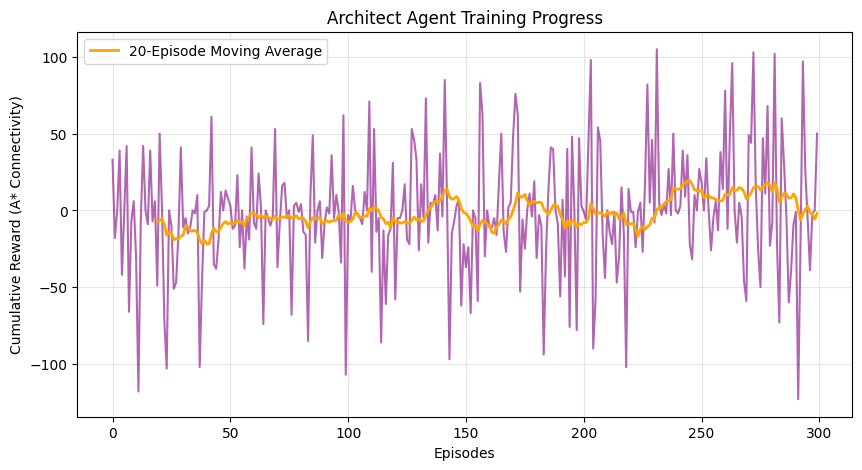

In [9]:
# cell 5: Visualization and Results

import pandas as pd

# training curve
plt.figure(figsize=(10, 5))
plt.plot(reward_history, color='purple', alpha=0.6)

# moving average
moving_avg = pd.Series(reward_history).rolling(window=20).mean()
plt.plot(moving_avg, color='orange', linewidth=2, label='20-Episode Moving Average')

plt.title('Architect Agent Training Progress')
plt.xlabel('Episodes')
plt.ylabel('Cumulative Reward (A* Connectivity)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

The training graph demonstrates a clear, successful learning trend, as the 20-episode moving average steadily climbs out of the initial penalty zone and stabilizes in positive territory by episode 250. Despite the high variance typical of deep reinforcement learning exploration, the dense cluster of high-reward spikes reaching up to +100 in the final third of training confirms the Architect has successfully learned the spatial logic required to satisfy the A* connectivity constraints.